In [4]:
import pandas as pd

# Read the Excel file
df = pd.read_excel('/content/sample_data/raw_dataset2.xlsx')

# Display the first 5 rows
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [5]:
# 1. Check the number of rows and columns
print("Dataset Shape:", df.shape)

# 2. Display all column names
print("\nColumn Names:")
print(df.columns.tolist())

# 3. Check the data types and missing values
print("\nDataset Information:")
df.info()

Dataset Shape: (1200, 14)

Column Names:
['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object   

In [6]:
# Check missing values in each column
print("Missing Values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

Duplicate Rows:
0


In [7]:
# Display basic statistics for numerical columns
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [8]:
# Select numerical columns
numeric_df = df.select_dtypes(include='number')

# Calculate basic statistics
statistics = pd.DataFrame({
    'Count': numeric_df.count(),
    'Mean': numeric_df.mean(),
    'Median': numeric_df.median(),
    'Minimum': numeric_df.min(),
    'Maximum': numeric_df.max()
})

statistics

,Count,Mean,Median,Minimum,Maximum
Quantity,1200,2.945833,3.000,1.00,5.00
UnitPrice,1200,356.412750,364.210,11.39,699.93
ItemsInCart,1200,5.485000,5.000,1.00,10.00
TotalPrice,1200,1053.968300,823.615,11.39,3456.40


In [9]:
# Count how many orders each product has
product_counts = df['Product'].value_counts()

# Display the top 10 products
product_counts.head(10)

,count
Product,
Printer,181
Tablet,179
Chair,178
Laptop,173
Desk,170
Monitor,163
Phone,156


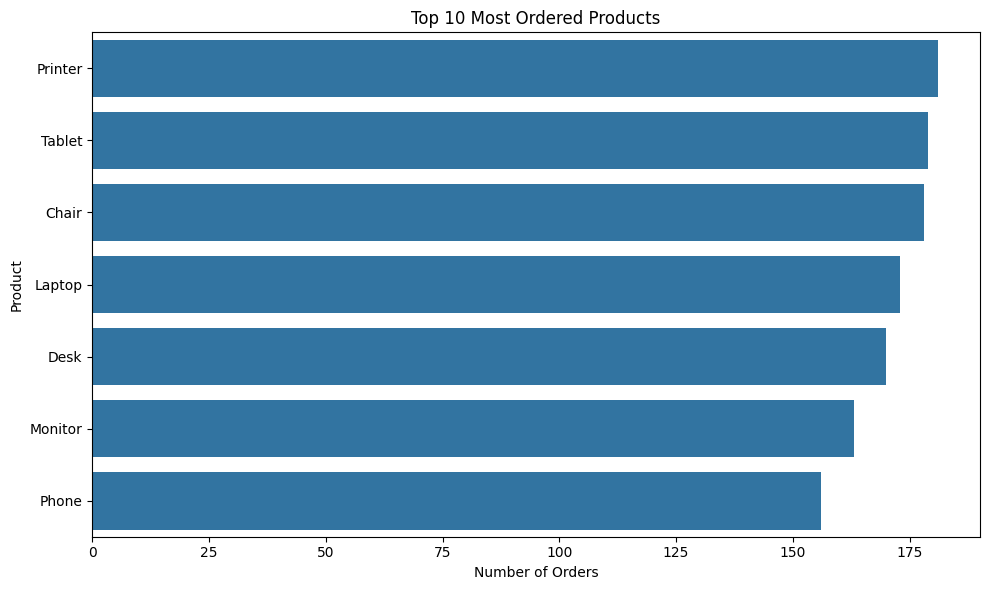

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the top 10 most ordered products
top_products = df['Product'].value_counts().head(10)

# Create the chart
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title('Top 10 Most Ordered Products')
plt.xlabel('Number of Orders')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

In [12]:
df.columns.tolist()

['OrderID',
 'Date',
 'CustomerID',
 'Product',
 'Quantity',
 'UnitPrice',
 'ShippingAddress',
 'PaymentMethod',
 'OrderStatus',
 'TrackingNumber',
 'ItemsInCart',
 'CouponCode',
 'ReferralSource',
 'TotalPrice']

In [13]:
# Display columns containing the word "payment"
[col for col in df.columns if 'payment' in col.lower()]

['PaymentMethod']

In [18]:
[col for col in df.columns if 'status' in col.lower()]

['OrderStatus']

In [20]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Display cleaned column names
print(df.columns.tolist())

['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']


In [21]:
# Display the unique values and counts for categorical columns
categorical_columns = df.select_dtypes(include='object').columns

for column in categorical_columns:
    print("\nColumn:", column)
    print(df[column].value_counts().head(10))


Column: OrderID
OrderID
ORD201183    1
ORD201182    1
ORD201181    1
ORD201180    1
ORD201179    1
ORD201178    1
ORD201177    1
ORD201176    1
ORD201175    1
ORD201174    1
Name: count, dtype: int64

Column: CustomerID
CustomerID
C46651    2
C56969    2
C35852    2
C38840    2
C97593    2
C21191    2
C14847    2
C91155    2
C98474    2
C70659    2
Name: count, dtype: int64

Column: Product
Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

Column: ShippingAddress
ShippingAddress
533 Main St    8
895 Main St    6
696 Main St    5
562 Main St    5
146 Main St    5
636 Main St    5
747 Main St    5
740 Main St    5
128 Main St    4
891 Main St    4
Name: count, dtype: int64

Column: PaymentMethod
PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

Column: OrderStatus
OrderStatus
Cancelled    250
Returned     247
Pend

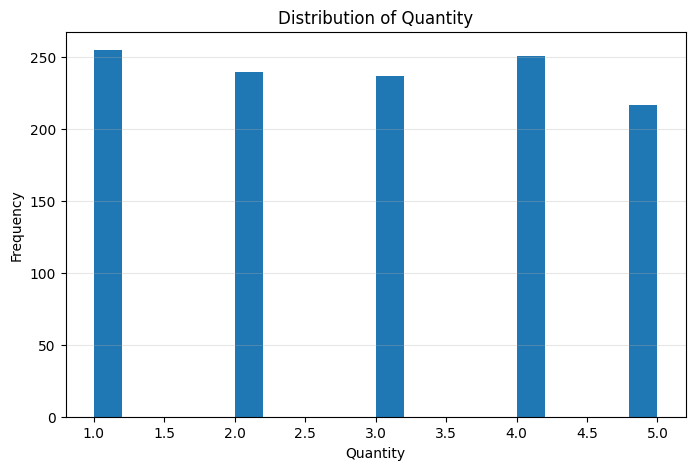

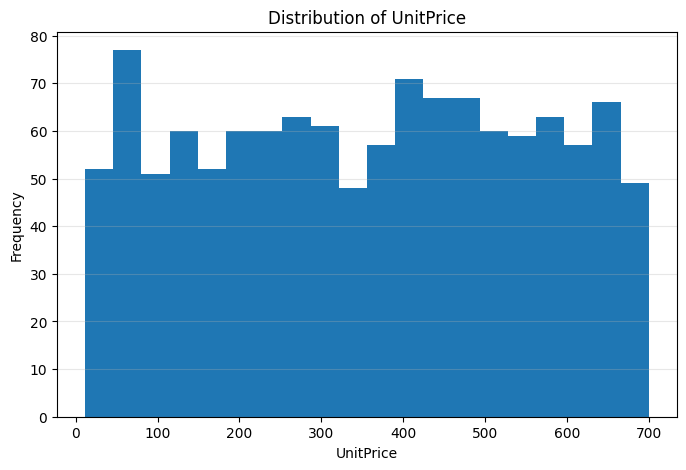

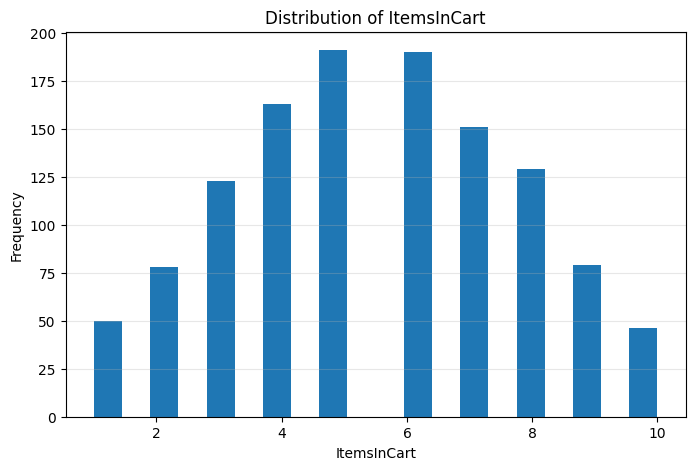

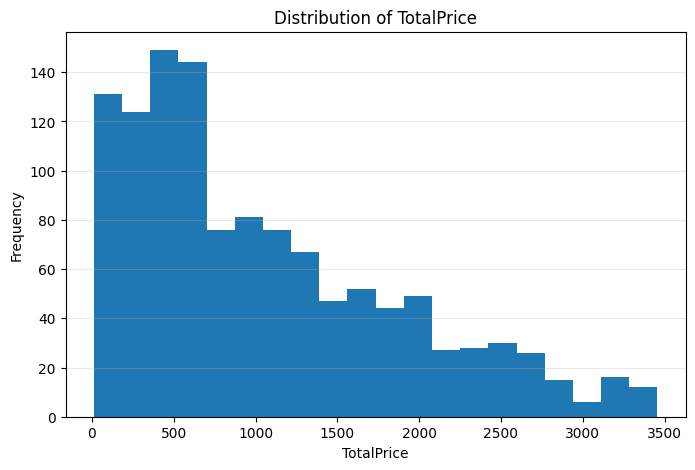

In [22]:
import matplotlib.pyplot as plt

# Select numerical columns
numeric_columns = df.select_dtypes(include='number').columns

# Create a histogram for each numerical column
for column in numeric_columns:
    plt.figure(figsize=(8, 5))
    plt.hist(df[column].dropna(), bins=20)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.3)
    plt.show()

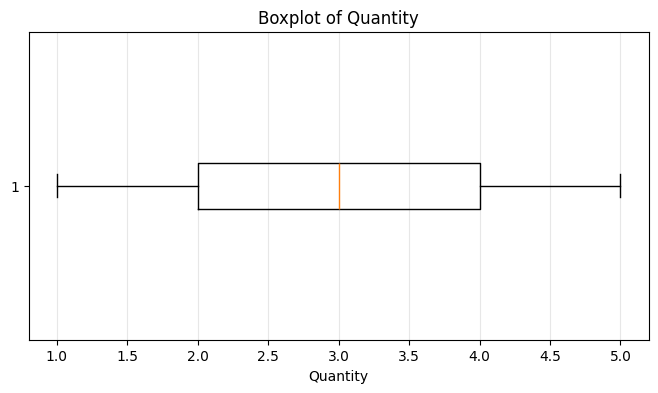

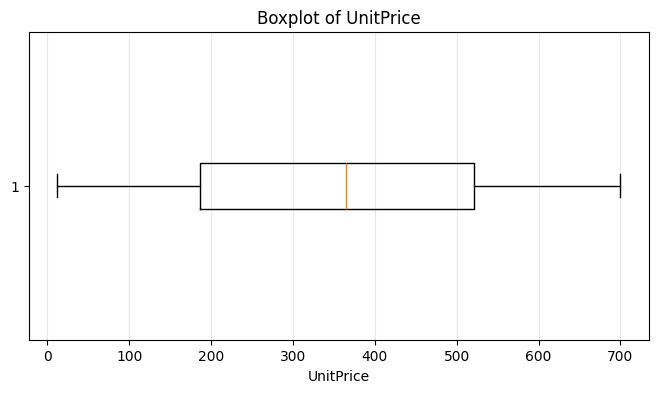

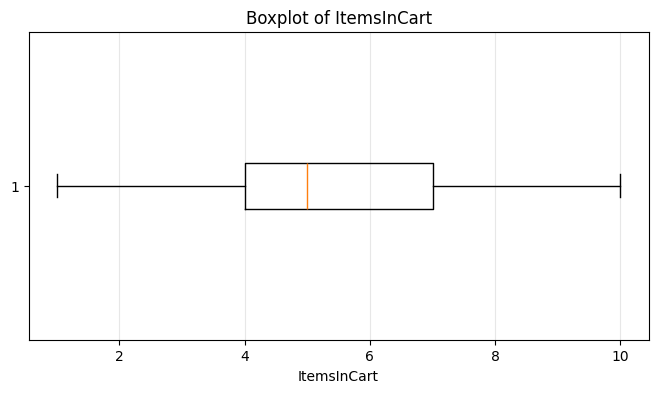

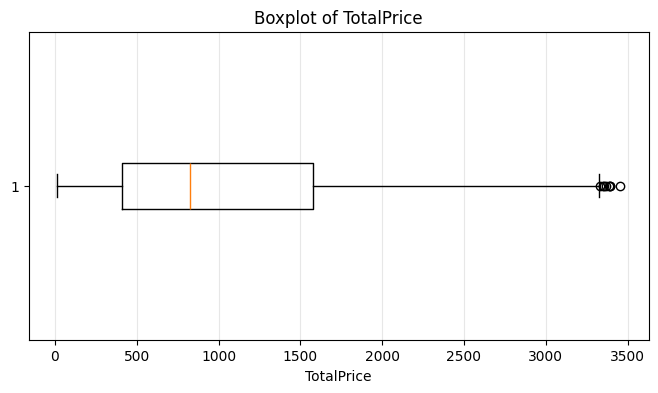

In [23]:
import matplotlib.pyplot as plt

# Select numerical columns
numeric_columns = df.select_dtypes(include='number').columns

# Create a boxplot for each numerical column
for column in numeric_columns:
    plt.figure(figsize=(8, 4))

    plt.boxplot(df[column].dropna(), vert=False)

    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)
    plt.grid(axis='x', alpha=0.3)
    plt.show()

In [24]:
# Calculate outliers using the IQR method
outlier_summary = {}

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ]

    outlier_summary[column] = len(outliers)

outlier_summary

{'Quantity': 0, 'UnitPrice': 0, 'ItemsInCart': 0, 'TotalPrice': 8}

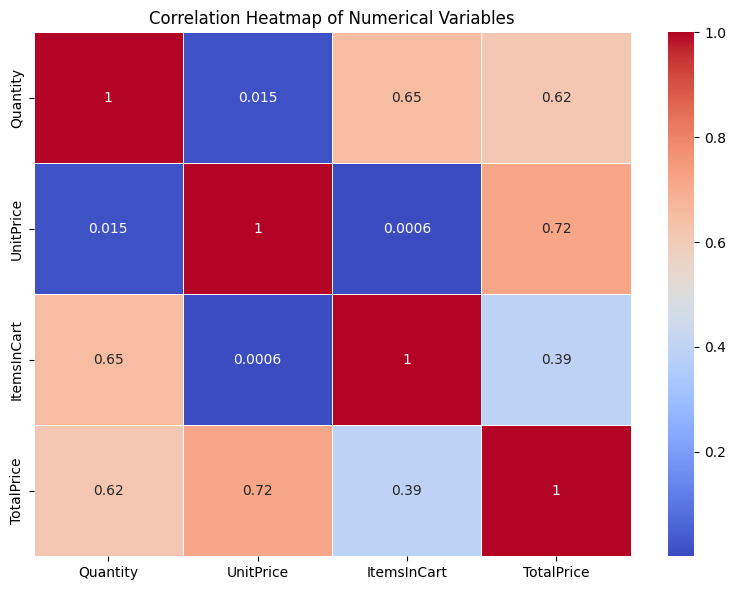

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlation between numerical columns
correlation = numeric_df.corr()

# Create the heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Numerical Variables')
plt.tight_layout()
plt.show()

In [5]:
# Display columns that may contain date information
date_columns = [
    column for column in df.columns
    if 'date' in column.lower() or 'time' in column.lower()
]

print("Possible date columns:", date_columns)

Possible date columns: ['Date']


In [6]:
df[date_columns].head()

,Date
0,2023-01-04
1,2024-08-23
2,2024-02-27
3,2023-10-15
4,2025-05-08


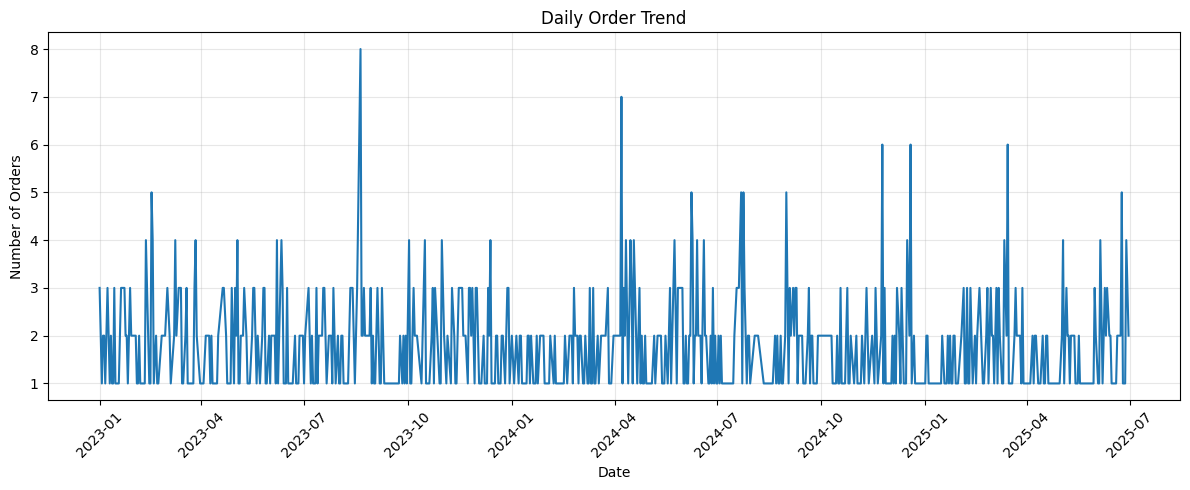

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert Date column into datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Count orders for each date
daily_orders = df.groupby('Date').size()

# Create the trend chart
plt.figure(figsize=(12, 5))

plt.plot(daily_orders.index, daily_orders.values)

plt.title('Daily Order Trend')
plt.xlabel('Date')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

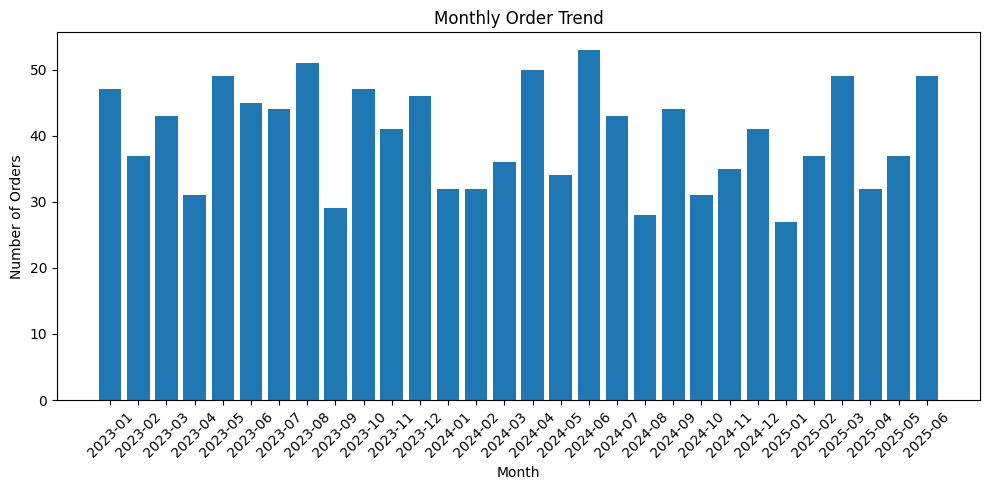

In [8]:
# Group orders by month
monthly_orders = df.groupby(
    df['Date'].dt.to_period('M')
).size()

# Convert month periods to strings for the chart
monthly_orders.index = monthly_orders.index.astype(str)

# Create the chart
plt.figure(figsize=(10, 5))

plt.bar(monthly_orders.index, monthly_orders.values)

plt.title('Monthly Order Trend')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
import pandas as pd

# Select numerical columns
numeric_df = df.select_dtypes(include='number')

# Calculate basic statistics
statistics = pd.DataFrame({
    'Count': numeric_df.count(),
    'Mean': numeric_df.mean(),
    'Median': numeric_df.median(),
    'Minimum': numeric_df.min(),
    'Maximum': numeric_df.max()
})

# Display the statistics
display(statistics)

,Count,Mean,Median,Minimum,Maximum
Quantity,1200,2.945833,3.000,1.00,5.00
UnitPrice,1200,356.412750,364.210,11.39,699.93
ItemsInCart,1200,5.485000,5.000,1.00,10.00
TotalPrice,1200,1053.968300,823.615,11.39,3456.40


In [12]:
print("EDA SUMMARY")
print("-" * 40)

print("Total number of records:", len(df))
print("Total number of columns:", len(df.columns))

print("\nNumerical Statistics:")
display(statistics)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nMost ordered products:")
print(df['Product'].value_counts().head(5))

print("\nDate range:")
print("Start date:", df['Date'].min())
print("End date:", df['Date'].max())

print("\nTotal sales:")
print(df['TotalPrice'].sum())

print("\nAverage order price:")
print(df['TotalPrice'].mean())

EDA SUMMARY
----------------------------------------
Total number of records: 1200
Total number of columns: 14

Numerical Statistics:


,Count,Mean,Median,Minimum,Maximum
Quantity,1200,2.945833,3.000,1.00,5.00
UnitPrice,1200,356.412750,364.210,11.39,699.93
ItemsInCart,1200,5.485000,5.000,1.00,10.00
TotalPrice,1200,1053.968300,823.615,11.39,3456.40



Missing values:
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

Duplicate rows: 0

Most ordered products:
Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Name: count, dtype: int64

Date range:
Start date: 2023-01-01 00:00:00
End date: 2025-06-30 00:00:00

Total sales:
1264761.96

Average order price:
1053.9683


In [13]:
# Count each order status
order_status_counts = df['OrderStatus'].value_counts()

display(order_status_counts)

,count
OrderStatus,
Cancelled,250
Returned,247
Pending,237
Shipped,235
Delivered,231


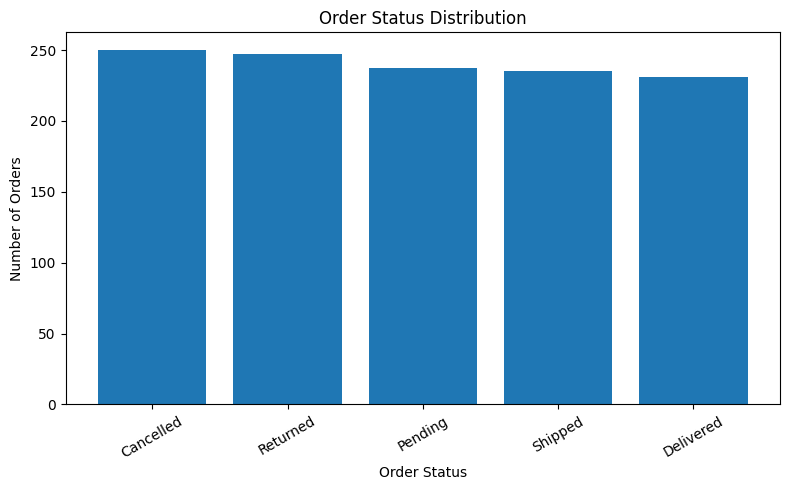

In [18]:
plt.figure(figsize=(8, 5))

plt.bar(
    order_status_counts.index,
    order_status_counts.values
)

plt.title('Order Status Distribution')
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [19]:
print("FINAL EDA REPORT")
print("=" * 50)

print("\n1. Dataset Overview")
print("Total records:", df.shape[0])
print("Total columns:", df.shape[1])

print("\n2. Data Quality")
print("Total missing values:", df.isnull().sum().sum())
print("Missing CouponCode values:", df['CouponCode'].isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

print("\n3. Numerical Analysis")
print("Average Quantity:", round(df['Quantity'].mean(), 2))
print("Average Unit Price:", round(df['UnitPrice'].mean(), 2))
print("Average Items in Cart:", round(df['ItemsInCart'].mean(), 2))
print("Average Total Price:", round(df['TotalPrice'].mean(), 2))
print("Maximum Total Price:", round(df['TotalPrice'].max(), 2))

print("\n4. Product Analysis")
print("Most ordered products:")
print(df['Product'].value_counts().head(5))

print("\n5. Order Status Analysis")
print(df['OrderStatus'].value_counts())

print("\n6. Payment Method Analysis")
print(df['PaymentMethod'].value_counts())

print("\n7. Date Range")
print("Start date:", df['Date'].min())
print("End date:", df['Date'].max())

FINAL EDA REPORT

1. Dataset Overview
Total records: 1200
Total columns: 14

2. Data Quality
Total missing values: 309
Missing CouponCode values: 309
Duplicate rows: 0

3. Numerical Analysis
Average Quantity: 2.95
Average Unit Price: 356.41
Average Items in Cart: 5.48
Average Total Price: 1053.97
Maximum Total Price: 3456.4

4. Product Analysis
Most ordered products:
Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Name: count, dtype: int64

5. Order Status Analysis
OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

6. Payment Method Analysis
PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

7. Date Range
Start date: 2023-01-01 00:00:00
End date: 2025-06-30 00:00:00


In [20]:
df.to_excel('/content/Final_EDA_Dataset.xlsx', index=False)

print("Final EDA dataset saved successfully!")

Final EDA dataset saved successfully!


In [21]:
# Save the dataset as a CSV file
df.to_csv('/content/Final_EDA_Dataset.csv', index=False)

print("CSV file saved successfully!")

CSV file saved successfully!


In [23]:
from google.colab import files

files.download('/content/Final_EDA_Dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>